# Network Analysis Sandbox
This notebook loads the stock similarity matrix and builds a network using the logic from `main.py`. Use the cells below to explore the graph structure and run custom analysis.

In [36]:
import sys
import os
from pathlib import Path
from collections import defaultdict

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add project root to sys.path to allow importing main.py
sys.path.append(os.path.abspath('.'))

print(sys.path)


from main import build_network

# --- Configuration & Static Data ---
OUTPUT_DIR = Path("output")
METADATA_DIR = Path("ticker_metadata")

# Industry Division Lookup System
DIVISIONS = {
    range(100, 1000): "Agriculture, Forestry and Fishing",
    range(1000, 1500): "Mining",
    range(1500, 1800): "Construction",
    range(1800, 2000): "Not Used",
    range(2000, 4000): "Manufacturing",
    range(4000, 5000): "Transportation, Communications, Electric, Gas and Sanitary Service",
    range(5000, 5200): "Wholesale Trade",
    range(5200, 6000): "Retail Trade",
    range(6000, 6800): "Finance, Insurance and Real Estate",
    range(7000, 9000): "Services",
    range(9100, 9730): "Public administration",
    range(9900, 10000): "Nonclassifiable",
}

['/Users/kunalsinghal/.local/share/uv/python/cpython-3.12.11-macos-aarch64-none/lib/python312.zip', '/Users/kunalsinghal/.local/share/uv/python/cpython-3.12.11-macos-aarch64-none/lib/python3.12', '/Users/kunalsinghal/.local/share/uv/python/cpython-3.12.11-macos-aarch64-none/lib/python3.12/lib-dynload', '', '/Users/kunalsinghal/networks-project/.venv/lib/python3.12/site-packages', '/Users/kunalsinghal/networks-project', '/Users/kunalsinghal/networks-project', '/Users/kunalsinghal/networks-project', '/Users/kunalsinghal/networks-project', '/Users/kunalsinghal/networks-project', '/Users/kunalsinghal/networks-project', '/Users/kunalsinghal/networks-project']


In [28]:
def load_graph_data():
    similarity_file = OUTPUT_DIR / "ticker_similarities.csv"
    if not similarity_file.exists():
        raise FileNotFoundError(f"{similarity_file} not found. Run data_processor.py first.")

    sim_df = pd.read_csv(similarity_file, index_col=0)
    cosine_dist = 1.0 - sim_df.values
    dist_df = pd.DataFrame(cosine_dist, index=sim_df.index, columns=sim_df.columns)

    G = build_network(dist_df)
    print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")
    return G

def get_division_name(sic_code):
    try:
        code = int(sic_code)
        for code_range, division in DIVISIONS.items():
            if code in code_range:
                return division
    except (ValueError, TypeError):
        pass
    return None

def load_metadata():
    tickers_path = METADATA_DIR / "tickers.txt"
    siccd_path = METADATA_DIR / "ticker_siccd.txt"

    ticker_names = {}
    if tickers_path.exists():
        df_names = pd.read_csv(tickers_path, sep="\t")
        ticker_names = dict(zip(df_names["ticker"], df_names["name"]))

    ticker_industries = {}
    if siccd_path.exists():
        df_siccd = pd.read_csv(siccd_path, sep="\t")
        ticker_industries = dict(zip(df_siccd["ticker"], df_siccd["siccd"]))

    return ticker_names, ticker_industries

# Initialization
G = load_graph_data()
ticker_names, ticker_industries = load_metadata()

# Filter out tickers with invalid or missing industry divisions
ticker_divisions = {}
for t, sic in ticker_industries.items():
    div = get_division_name(sic)
    if div:
        ticker_divisions[t] = div

print(f"Mapped {len(ticker_divisions)} tickers to valid industry divisions.")

# List stock counts per industry
print("\nStock Counts per Industry Division:")
div_counts = pd.Series(ticker_divisions.values()).value_counts()
for div, count in div_counts.items():
    print(f" - {div}: {count}")

Building a dense graph from distance matrix...
Graph built with 2441 nodes and 2978020 edges.
Graph loaded: 2441 nodes, 2978020 edges.
Mapped 5005 tickers to valid industry divisions.

Stock Counts per Industry Division:
 - Finance, Insurance and Real Estate: 1862
 - Manufacturing: 919
 - Nonclassifiable: 851
 - Services: 535
 - Transportation, Communications, Electric, Gas and Sanitary Service: 309
 - Mining: 211
 - Retail Trade: 153
 - Wholesale Trade: 108
 - Construction: 47
 - Agriculture, Forestry and Fishing: 7
 - Public administration: 3


In [29]:
def build_industry_network(G_base, ticker_divs):
    # 1. Group tickers by their division (ticker_divs is already filtered for valid divisions)
    division_to_tickers = defaultdict(list)
    for ticker in G_base.nodes():
        div = ticker_divs.get(ticker)
        # Only include tickers that have a valid mapped division
        if div:
            division_to_tickers[div].append(ticker)

    # 2. Build the Industry-Level Graph
    G_ind = nx.Graph()
    divisions = sorted(list(division_to_tickers.keys()))

    for i in range(len(divisions)):
        for j in range(i, len(divisions)):
            div_a = divisions[i]
            div_b = divisions[j]

            tickers_a = division_to_tickers[div_a]
            tickers_b = division_to_tickers[div_b]

            # Collect weights of edges between these two groups
            weights = []
            for t_a in tickers_a:
                for t_b in tickers_b:
                    if t_a == t_b: continue
                    if G_base.has_edge(t_a, t_b):
                        weights.append(G_base[t_a][t_b]['weight'])

            if weights:
                avg_weight = sum(weights) / len(weights)
                G_ind.add_edge(div_a, div_b, weight=avg_weight, count=len(weights))

    return G_ind

G_industry = build_industry_network(G, ticker_divisions)
print(f"Industry network built with {G_industry.number_of_nodes()} divisions.")

Industry network built with 11 divisions.


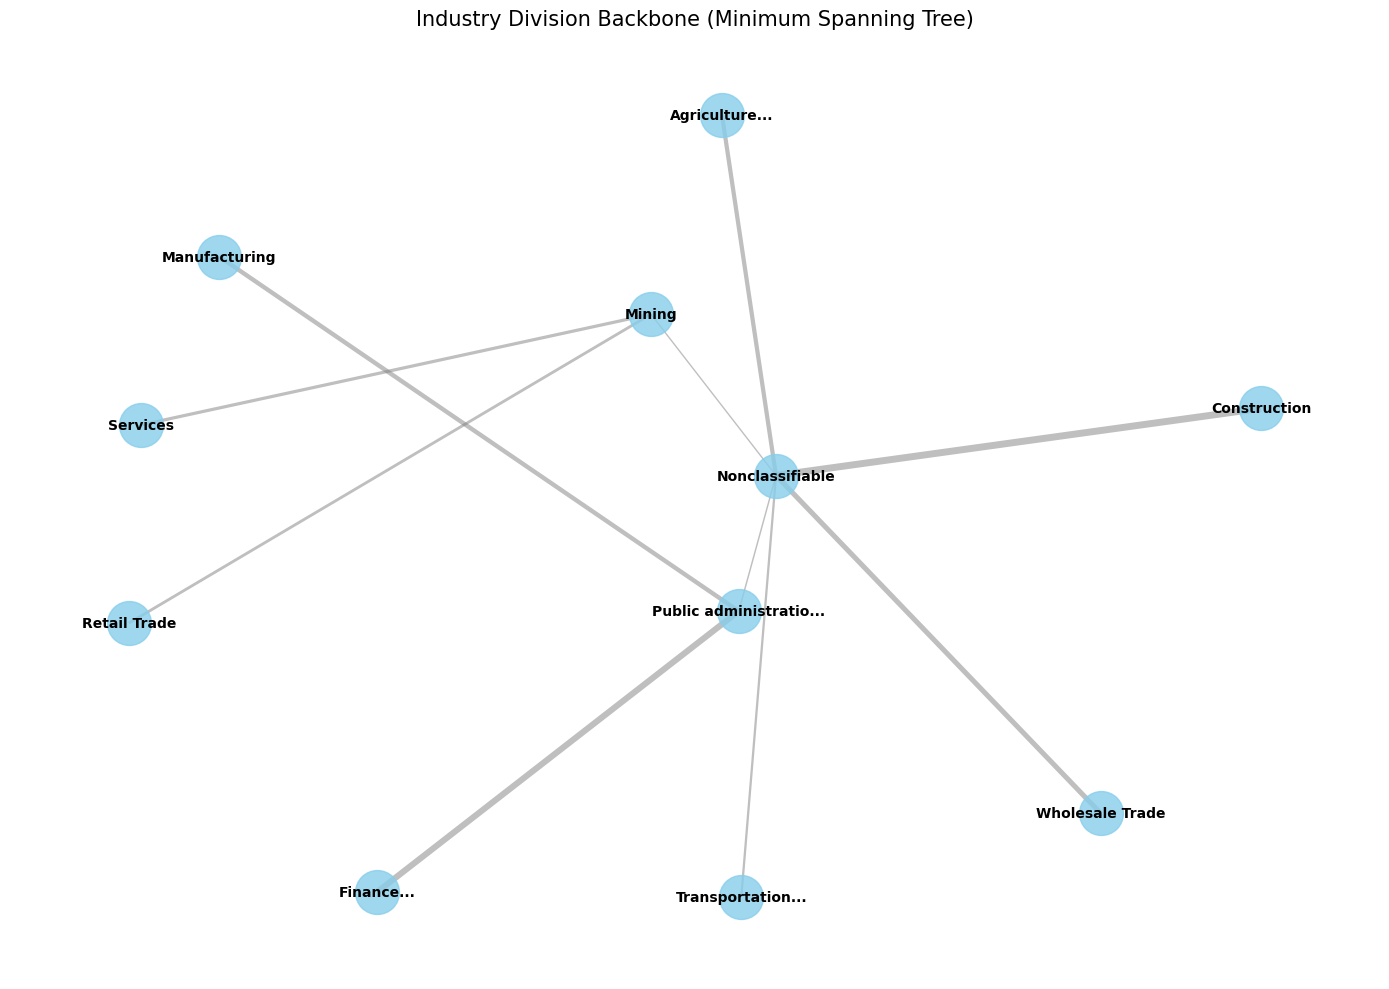

In [34]:
def visualize_backbone(graph):
    T_ind = nx.maximum_spanning_tree(graph, weight="weight")

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(T_ind, k=1.5, seed=42)

    all_weights = [d['weight'] for u, v, d in T_ind.edges(data=True)]
    min_w, max_w = min(all_weights), max(all_weights)

    def get_width(w):
        return (1 - (w - min_w) / (max_w - min_w + 1e-6)) * 4 + 1

    edge_widths = [get_width(d['weight']) for u, v, d in T_ind.edges(data=True)]

    nx.draw_networkx_nodes(T_ind, pos, node_size=1000, node_color='skyblue', alpha=0.8)
    nx.draw_networkx_edges(T_ind, pos, width=edge_widths, edge_color='gray', alpha=0.5)

    labels = {n: n.split(',')[0][:20] + '...' if len(n) > 20 else n for n in T_ind.nodes()}
    nx.draw_networkx_labels(T_ind, pos, labels=labels, font_size=10, font_weight='bold')

    plt.title("Industry Division Backbone (Minimum Spanning Tree)", fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_backbone(G_industry)

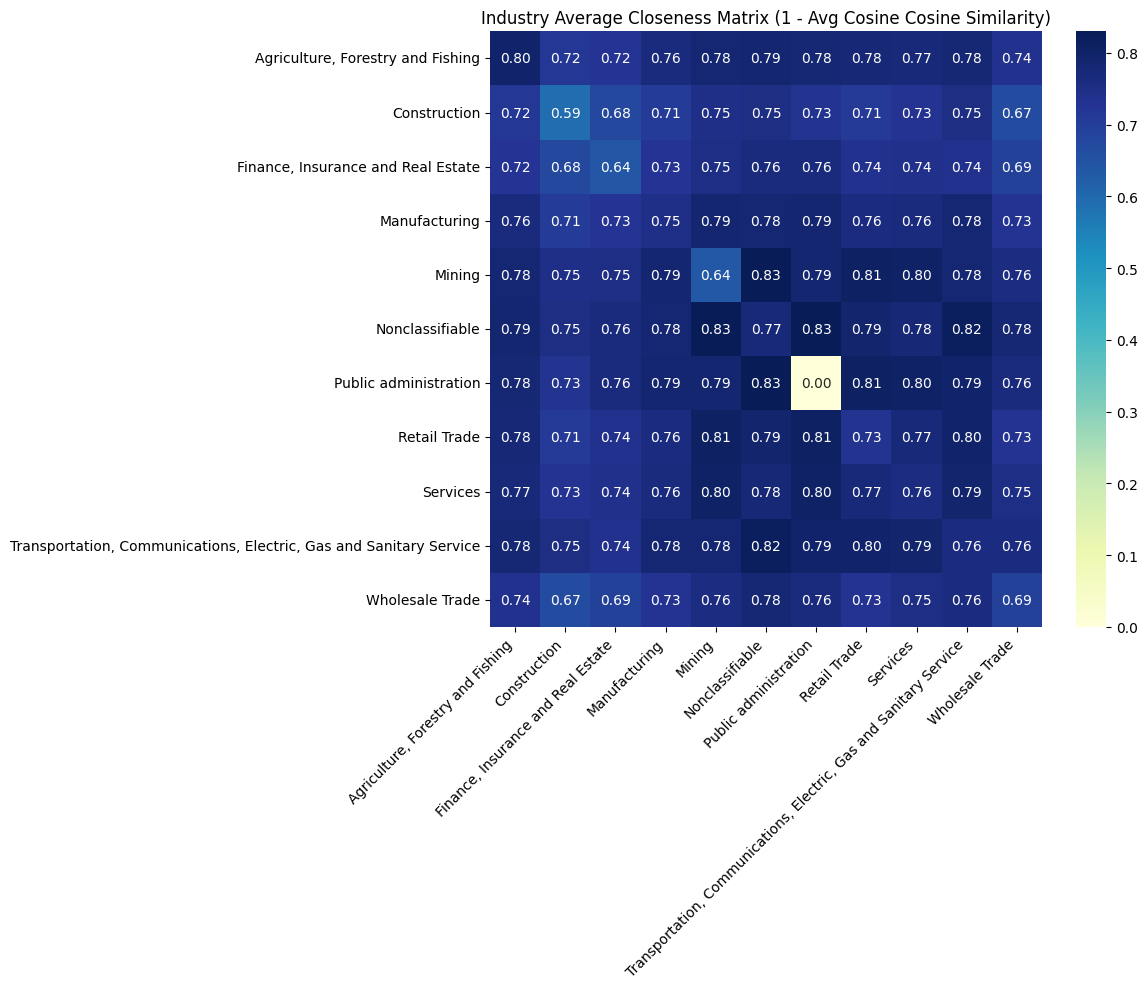

In [35]:
def display_industry_closeness_matrix(G_ind):
    # Convert the industry graph to a distance matrix
    # Note: Using 1 - distance for a 'closeness' heatmap
    nodes = sorted(list(G_ind.nodes()))
    matrix = nx.to_pandas_adjacency(G_ind, nodelist=nodes, weight='weight')

    # Fill gaps (diagonal and any missing edges)
    # Cosine distance 0 means identical, so similarity is 1.0

    import seaborn as sns
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu",
                xticklabels=nodes, yticklabels=nodes)

    plt.title("Industry Average Closeness Matrix (1 - Avg Cosine Cosine Similarity)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

display_industry_closeness_matrix(G_industry)

In [32]:
# Check specific connection
u, v = "Public administration", "Nonclassifiable"
if G_industry.has_edge(u, v):
    d = G_industry[u][v]
    print(f"Connection: {u} <-> {v}")
    print(f" - Avg Distance: {d['weight']:.4f}")
    print(f" - Pair Count: {d['count']}")

    # Check if it's in the MST
    T_industry = nx.minimum_spanning_tree(G_industry, weight="weight")
    if T_industry.has_edge(u, v):
        print(" - Status: Correctly included in the MST backbone.")
    else:
        print(" - Status: NOT in MST (a shorter path exists through other nodes).")


Connection: Public administration <-> Nonclassifiable
 - Avg Distance: 0.8290
 - Pair Count: 362
 - Status: NOT in MST (a shorter path exists through other nodes).
